### Reconociendo dibujos a mano a partir del aprendizaje automatizado

En noviembre de 2016, la empresa internacional Google lanzó un juego online llamado "Quick, Draw!" que le pedía al jugador dibujar un objeto en particular, para después hacer pasar su dibujo por una red neuronal y tratar de identificar a qué se refería. [3]

Se colectaron más de 50 millones de imágenes de 345 diferentes categorías, entre las que se encuentran aviones, relojes, mariposas, inclusive, la Torre Eiffel. Y los datos recopilados se subieron a la nube de manera pública para que, quien estuviera interesado, creara sus propios proyectos y entrenara sus redes neuronales a partir de ellos.

La justificación de este problema tiene dos enfoques diferentes. En primer lugar, puede ser utilizado para analizar problemas de visión en niños, sus patrones de aprendizaje, y sus emociones al momento de realizar los dibujos. Por otro lado, usar esta basta base de datos tiene varios beneficios, sobre todo al momento de entrenar grandes redes neuronales:

--> Trazos incompletos e irregulares. Esta característica de los dibujos obliga a las redes neuronales a no aprender patrones particulares, sino a generalizar estructuras.

--> Baja resolución. Principalmente, cuando se busca entrenar una red neuronal a falta de potencia computacional, se puede perfectamente usar esta base de datos, pues las imágenes extraídas pueden reducirse a una baja resolución sin perder tanta información.

Personalmente, me interesó mucho explorar las diferentes categorías de esta base de datos. En este proyecto utilicé solamente trazos de círculos, cuadrados y triángulos, pero se puede extrapolar a 345 categorías, lo que incrementa en gran medida las posibilidades de nuevos proyectos.

[Link del repositorio de Google](https://github.com/googlecreativelab/quickdraw-dataset)

[Link del dataset](https://console.cloud.google.com/storage/browser/quickdraw_dataset/)

Se han utilizado los archivos 'simplified', que han sido previamente procesados. Algunas de las ventajas que tiene esta sub-base de datos es que se han alineado los dibujos a las esquinas del lienzo, se han escalado los pixeles a tener valores entre 0 y 255, y que se han simplificado los trazos, para hacerlos más limpios.

Estos archivos tienen terminación .ndjson, por lo que previamente hay que trabajarlos para convertirlos a arreglos de Numpy.

In [45]:
#Importamos las librerías
import json
import cv2 #Instalamos antes usando pip install opencv-python

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import GlobalAveragePooling2D
from sklearn.model_selection import train_test_split


from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

Definimos la función que tomará los trazos, que no son imágenes, sino coordenadas de puntos, dibujará pixeles a partir de ellos y regresará la imagen interpolada o redimensionada al tamaño que deseamos. 

La información de la estructura de la base de datos usada ha sido obtenida de [4].

In [46]:
def dibujo_a_imagen(drawing, size=96): #Queremos que las imágenes sean de (96,96)
    # Hacemos un lienzo más grande para tener trazos más finos antes de reducirlo a (96,96)
    lienzo = np.zeros((256, 256), dtype=np.uint8) #uint8 hace que los valores estén entre  0 y 255

    for trazo in drawing:
        '''En el dataset, cada drawing es una lista de trazos
        y cada trazo contiene dos listas, una de puntos en X y la otra de puntos en Y'''
        x_points = trazo[0]
        y_points = trazo[1]

        for i in range(len(x_points) - 1): #Con esto dibujamos segmentos (tomando puntos iniciales y finales)
            x1 = x_points[i]
            y1 = y_points[i]
            x2 = x_points[i+1]
            y2=y_points[i+1]
            cv2.line(lienzo, (x1, y1), (x2, y2), color=255, thickness=2)

    # Redimensionamos al tamaño final
    lienzo = cv2.resize(lienzo, (size, size), interpolation=cv2.INTER_AREA)

    return lienzo

Comenzamos primero por guardar los círculos

In [47]:
#Definimos las listas donde éstos serán guardados
X_circle = []
Y_circle = []

with open("simplified_circle.ndjson", "r") as f:
    for linea in f:
        data = json.loads(linea) #Cada línea del archivo ndjson tiene un dibujo diferente

        if data['recognized']==True: #Seleccionamos sólo las imágenes reconocidas previamente por Google AI
            drawing = data["drawing"]
            imagen = dibujo_a_imagen(drawing, size=96) #Llamamos a la función previamente definida
            datos=np.asarray(imagen)
            datos=np.expand_dims(datos,-1) #Redimensionamos a 2 coordenadas y 1 canal, es decir, (96,96,1)
            #Recordemos que los dibujos ya vienen normalizados entre 0 y 255.
            img_prep = tf.keras.applications.mobilenet_v2.preprocess_input(datos) #La escala a valores entre -1 y 1
            X_circle.append(img_prep)
            Y_circle.append(0)  # Añadimos las etiquetas, 0 para los círculos
        else:
            continue
        

X_circle = np.array(X_circle)
Y_circle = np.array(Y_circle)

print(X_circle.shape)
#Cargamos solamente 300 imágenes
X_circle=X_circle[:300]
Y_circle=Y_circle[:300]
print('\n',X_circle.shape)

(118808, 96, 96, 1)

 (300, 96, 96, 1)


In [48]:
#Podemos comprobar que la imagen tiene pixeles con valores entre -1 y 1
print(np.min(X_circle[1]),np.max(X_circle[1]))

-1.0 1.0


0


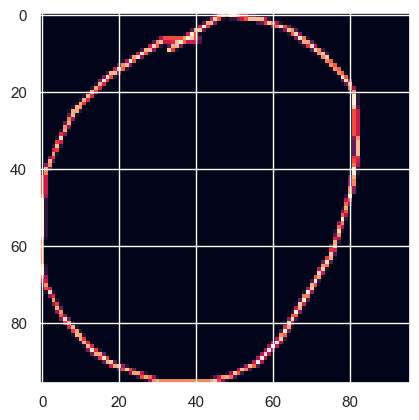

In [49]:
#Mostramos el primer elemento
plt.imshow(X_circle[0])
print(Y_circle[0])

Hacemos lo mismo con el archivo de triángulos

In [50]:
X_triangle = []
Y_triangle = []

with open("simplified_triangle.ndjson", "r") as f:
    for linea in f:
        data = json.loads(linea)

        if data['recognized']==True:
            drawing = data["drawing"]
            imagen = dibujo_a_imagen(drawing, size=96) #Llamar a la función
            datos=np.asarray(imagen)
            datos=np.expand_dims(datos,-1) #Redimensionar
            img_prep = tf.keras.applications.mobilenet_v2.preprocess_input(datos) #Escalar
            X_triangle.append(img_prep)
            Y_triangle.append(1) #Etiqueta 1 para los triángulos
        else:
            continue
        
X_triangle = np.array(X_triangle)
Y_triangle = np.array(Y_triangle)
print(X_triangle.shape)
#Cargamos solamente 300 imágenes
X_triangle=X_triangle[:300]
Y_triangle=Y_triangle[:300]
print("\n",X_triangle.shape)

(120500, 96, 96, 1)

 (300, 96, 96, 1)


1


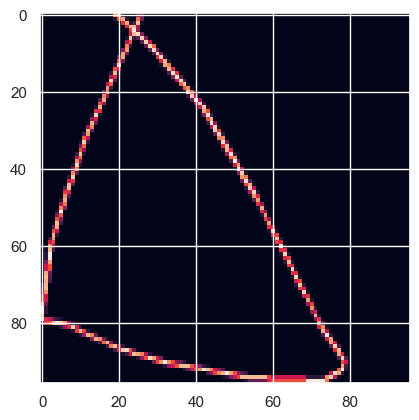

In [51]:
plt.imshow(X_triangle[0])
print(Y_triangle[0])

Repetimos para los cuadrados

In [52]:
X_square = []
Y_square = []

with open("simplified_square.ndjson", "r") as f:
    for linea in f:
        data = json.loads(linea)

        if data['recognized']==True:
            drawing = data["drawing"]
            imagen = dibujo_a_imagen(drawing, size=96) #Llamar a la función
            datos=np.asarray(imagen) 
            datos=np.expand_dims(datos,-1) #Redimensionar
            img_prep = tf.keras.applications.mobilenet_v2.preprocess_input(datos) #Escalar
            X_square.append(img_prep)
            Y_square.append(2) #Etiqueta 2 para los cuadrados
        else:
            continue
        
X_square = np.array(X_square)
Y_square = np.array(Y_square)
print(X_square.shape)
#Cargamos solamente 300 imágenes
X_square=X_square[:300]
Y_square=Y_square[:300]
print("\n",X_square.shape)

(120538, 96, 96, 1)

 (300, 96, 96, 1)


2


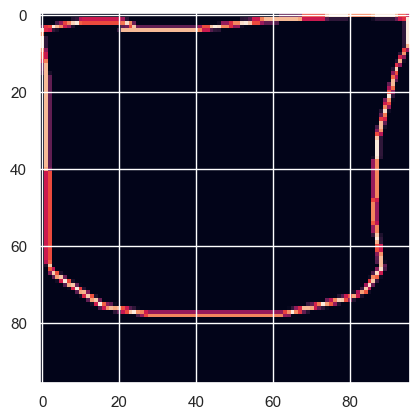

In [53]:
plt.imshow(X_square[0])
print(Y_square[0])

In [54]:
#Unimos los datos
X = np.concatenate((X_circle,X_square,X_triangle))
Y = np.concatenate((Y_circle,Y_square,Y_triangle))
print(X.shape, Y.shape)
#Ocuparemos decirle al modelo que mezcle las imágenes y las etiquetas. Usamos train_test_split con shuffle=True

(900, 96, 96, 1) (900,)


In [55]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.3,shuffle=True)

Definimos el modelo base. Utilizamos MobileNetV2 de TensorFlow, puesto que es una arquitectura muy robusta para el reconocimiento de imágenes.

Es importante resaltar que esta red neuronal trabaja con 3 canales (RGB). [6] 

Es por eso que el input_shape no puede ser (96,96,1).

Para resolver este problema anidaremos varias capas. La primera será una capa de entrada, Input, a la cual le pasaremos las imágenes de (96,96,1). Luego pondremos una capa convolucional (que triplicará los canales manteniendo las dimensiones) logrando así imágenes de (96,96,3) y después podremos colocar el modelo base de MobileNetV2.

La información de cómo usar la capa convolucional se obtuvo de [7].

In [69]:
#Cargamos el extractor de características. Las capas 'top' son las de clasificación, las cuales quitamos para nosotros definir estas capas de acuerdo a nuestro problema.
base_model = tf.keras.applications.MobileNetV2(input_shape=(96,96,3), include_top=False, weights='imagenet')

#Congelamos el modelo para que no se entrenen los pesos
base_model.trainable = False
#base_model.summary()

#Como vemos, hay que aplicar una capa de aplanado al final

In [70]:
# Definimos el modelo
# El padding y el stride definidos de esta manera mantienen las dimensiones de entrada (96,96), y los 3 filtros crean los 3 canales necesarios

model=Sequential([
    Input(shape=(96,96,1)),
    Conv2D(activation='linear',filters=3,kernel_size=(3,3),strides=(1,1),padding='same'),
    base_model,
    GlobalAveragePooling2D(),
    Dense(units=16, activation='relu'),
    Dense(units=3, activation='softmax')
])
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 96, 96, 3)      │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │        20,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,278,561 (8.69 MB)

 Trainable params: 20,577 (80.38 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [71]:
#Compilamos el modelo usando el optimizador Adam y la pérdida sparse_categorical_crossentropy para varias categorías
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

In [72]:
#Entrenamos el modelo con 7 épocas y un batch size de 128

model.fit(
    X_train,Y_train,
    epochs=7,
    batch_size=128, verbose=2
)

Epoch 1/7
5/5 - 8s - 2s/step - accuracy: 0.7063 - loss: 0.7433
Epoch 2/7
5/5 - 3s - 655ms/step - accuracy: 0.9746 - loss: 0.1796
Epoch 3/7
5/5 - 3s - 634ms/step - accuracy: 0.9825 - loss: 0.0689
Epoch 4/7
5/5 - 3s - 639ms/step - accuracy: 0.9905 - loss: 0.0405
Epoch 5/7
5/5 - 3s - 639ms/step - accuracy: 0.9921 - loss: 0.0288
Epoch 6/7
5/5 - 3s - 633ms/step - accuracy: 0.9937 - loss: 0.0213
Epoch 7/7
5/5 - 3s - 637ms/step - accuracy: 0.9937 - loss: 0.0169


In [73]:
'''Realizamos la predicción. Como tenemos 3 neuronas en la última capa,
 obtendremos un arreglo de N filas y 3 columnas a la salida.
 Por ello, calculamos el índice con mayor probabilidad de cada fila usando np.argmax (nos devuelve 0, 1 o 2).'''
Y_pred=model.predict(X_test)
N=len(Y_pred[:,0])
b=[]
for i in range(N):
    indice_arg_max=np.argmax(Y_pred[i,:])
    b.append(indice_arg_max)
Y_pred=np.asarray(b)
print(Y_pred)

9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 269ms/step
[1 1 0 0 1 1 1 0 2 1 0 0 1 1 0 1 1 2 1 0 2 0 0 0 2 2 1 0 1 0 2 1 2 2 1 0 0
 0 0 1 2 2 0 2 0 0 1 0 2 2 1 2 0 2 2 1 0 2 0 2 2 2 1 1 0 1 1 2 1 1 1 0 1 0
 0 2 2 0 0 2 1 2 1 0 0 1 2 0 1 2 2 2 1 0 0 1 1 0 0 2 0 2 0 0 0 2 1 0 1 1 0
 0 0 1 1 1 1 1 1 0 0 0 0 2 2 0 0 1 2 2 1 2 2 1 0 0 1 0 2 2 0 1 0 1 1 2 1 2
 1 2 2 0 1 2 1 0 0 0 1 0 0 1 2 0 2 1 0 0 1 1 2 2 2 2 2 2 0 1 2 0 0 1 1 1 0
 0 1 1 0 1 1 2 1 1 1 2 1 1 1 1 2 1 1 2 1 1 1 1 0 1 1 0 0 1 1 0 2 1 0 0 2 0
 1 0 1 2 0 1 1 0 0 2 2 1 0 0 0 1 1 2 0 1 2 2 2 0 2 2 0 2 1 0 1 0 2 0 0 2 1
 1 2 0 2 2 2 0 1 0 0 0]


In [74]:
#Imprimimos el reporte de clasificación
target_names=['Círculos', 'Triángulos', 'Cuadrados']
print('----- Reporte de clasificación ------')
print(classification_report(Y_test, Y_pred ,target_names=target_names))

----- Reporte de clasificación ------
              precision    recall  f1-score   support

    Círculos       1.00      0.99      0.99        97
  Triángulos       0.99      1.00      0.99        97
   Cuadrados       0.99      0.99      0.99        76

    accuracy                           0.99       270
   macro avg       0.99      0.99      0.99       270
weighted avg       0.99      0.99      0.99       270



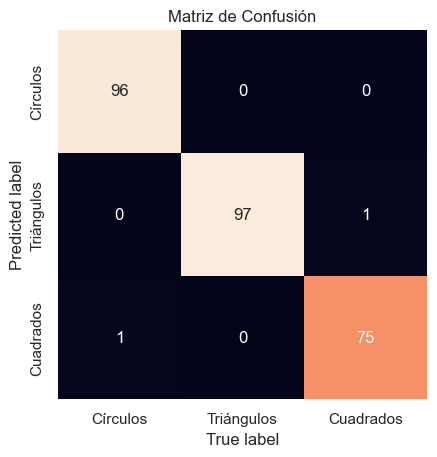

In [75]:
#Generamos la matriz de confusión  
plt.figure()
sns.set()               
mat = confusion_matrix(Y_test, Y_pred)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
    xticklabels=['Círculos', 'Triángulos', 'Cuadrados'],
    yticklabels=['Círculos', 'Triángulos', 'Cuadrados'])
plt.xlabel('True label')
plt.ylabel('Predicted label')
plt.title('Matriz de Confusión')
plt.show()

### Referencias
[1] TensorFlor.org (2022, Enero 26). Transferencia de aprendizaje y ajuste. https://www.tensorflow.org/tutorials/images/transfer_learning?hl=es-419 

[2] Ipinlaye O. & Mukherjee S. (2025, Abril 29). A Guide to Global Pooling in Neural Networks. https://www.digitalocean.com/community/tutorials/global-pooling-in-convolutional-neural-networks

[3] Waechter L. (2022, Abril 3). Recognizing hand drawn Doodles using Deep Learning. https://dev.to/larswaechter/recognizing-hand-drawn-doodles-using-deep-learning-ki0#:~:text=And%20that%27s%20exactly%20what%20this%20article%20is%20about%3A,predict%20them%20using%20the%20network%20model%20later%20on

[4] Mrayinteractive. (2025, Marzo 10). Quickdraw-dataset. https://github.com/googlecreativelab/quickdraw-dataset?tab=readme-ov-file#preprocessed-dataset

[5] Sckit Learn Developers. (2025). Train_test_split. https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

[6] Tensorflow. (2024, Junio 7). tf.keras.applications.MobileNetV2. https://www.tensorflow.org/api_docs/python/tf/keras/applications/MobileNetV2

[7] Geeksforgeeks. (2025, Julio 23). Python Tensorflow - tf.keras.layers.Conv2D() Function. https://www.geeksforgeeks.org/machine-learning/python-tensorflow-tf-keras-layers-conv2d-function/